In [1]:
import pandas as pd
df = pd.read_csv('../data/heart.csv')

In [2]:
%pip uninstall sklearn scikit-learn -y
%pip install scikit-learn mlxtend pandas


Found existing installation: scikit-learn 1.7.2
Uninstalling scikit-learn-1.7.2:
  Successfully uninstalled scikit-learn-1.7.2
Note: you may need to restart the kernel to use updated packages.


  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
Note: you may need to restart the kernel to use updated packages.


## 1. Discretizați atributele numerice; lucrați cu mai multe metode

In [3]:
def apply_discretization(data, strategy, n_bins=3):
    discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy=strategy)
    data_disc = data.copy()
    
    # Aplicăm discretizarea pe coloanele numerice
    data_disc[numeric_cols] = discretizer.fit_transform(data[numeric_cols])
    
    # Mapăm numerele la etichete pentru lizibilitate (0=Low, 1=Med, 2=High)
    mapping = {0.0: 'Low', 1.0: 'Medium', 2.0: 'High'}
    for col in numeric_cols:
        data_disc[col] = data_disc[col].map(mapping)
        
    # Pregătim datele pentru Apriori (One-Hot Encoding)
    # Adăugăm numele coloanei la valoare pentru a identifica regula: "Age=Low"
    for col in data_disc.columns:
        data_disc[col] = col + "=" + data_disc[col].astype(str)
        
    return pd.get_dummies(data_disc)

strategies = ['uniform', 'quantile'] #  Cod sursă pt metode de discretizare - https://machinelearningmastery.com/discretization-transforms-for-machine-learning/
# strategies = ['uniform', 'kmeans', 'quantile']

## 2. Fixați praguri pentru metricile suport și încredere

In [4]:

suport = [0.2, 0.3, 0.4]
conf = [0.7, 0.8, 0.9]

## 3. Extrageți regulile de asociere utilizând apriori (opțional și fp-growth); ordonați regulile după metricile discutate și identificați reguli ce pot căpăta o interpretare utilă

In [5]:
from sklearn.preprocessing import KBinsDiscretizer
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth

numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
categorical_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

results = {}
plot_data = []

for s in suport:
    for c in conf:
        print(f"Analiza regulilor de asociere (Suport={s}, Confidență={c}):\n")

        for strat in strategies:
            df_ready = apply_discretization(df, strategy=strat, n_bins=3)
            
            # Extragere seturi frecvente === apriori sau fpgrowth
            frequent_itemsets = apriori(df_ready, min_support=s, use_colnames=True)
            # frequent_itemsets = fpgrowth(df_ready, min_support=s, use_colnames=True)
            
            # Generare reguli
            rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=c)
            results[strat] = rules
            count = len(rules)
            
            print(f"Strategia {strat.upper()}: {count} reguli găsite.")

            # 3. Identificarea regulilor utile
            best_rules = results[strat].sort_values(by='lift', ascending=False).head(5)
            print("\nTop 5 reguli utile (Strategia Quantile):")
            pd.set_option('display.max_columns', None)
            pd.set_option('display.width', None)
            for idx, row in best_rules.iterrows():
                print(f"Antecedents: {row['antecedents']} => Consequents: {row['consequents']}")
                print(f"  Support: {row['support']:.4f}\n  Confidence: {row['confidence']:.4f}\n  Lift: {row['lift']:.4f}\n")
            
            plot_data.append({
                'Suport': s,
                'Incredere': c,
                'Strategie': strat,
                'NrReguli': count
            })

            print("-" * 80)

Analiza regulilor de asociere (Suport=0.2, Confidență=0.7):

Strategia UNIFORM: 872 reguli găsite.

Top 5 reguli utile (Strategia Quantile):
Antecedents: frozenset({'Oldpeak_Oldpeak=Low', 'HeartDisease_HeartDisease=0'}) => Consequents: frozenset({'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'})
  Support: 0.2462
  Confidence: 0.7986
  Lift: 2.5193

Antecedents: frozenset({'FastingBS_FastingBS=0', 'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Low', 'HeartDisease_HeartDisease=0'})
  Support: 0.2462
  Confidence: 0.7766
  Lift: 2.5193

Antecedents: frozenset({'Oldpeak_Oldpeak=Low', 'HeartDisease_HeartDisease=0', 'FastingBS_FastingBS=0'}) => Consequents: frozenset({'ST_Slope_ST_Slope=Up', 'ExerciseAngina_ExerciseAngina=N'})
  Support: 0.2462
  Confidence: 0.8828
  Lift: 2.4048

Antecedents: frozenset({'Oldpeak_Oldpeak=Low', 'HeartDisease_HeartDisease=0'}) => Consequents: frozenset({'ST_Slope_ST_Sl

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: Future

Strategia UNIFORM: 95 reguli găsite.

Top 5 reguli utile (Strategia Quantile):
Antecedents: frozenset({'Oldpeak_Oldpeak=Low', 'HeartDisease_HeartDisease=0', 'Sex_Sex=M'}) => Consequents: frozenset({'ST_Slope_ST_Slope=Up'})
  Support: 0.2004
  Confidence: 0.9634
  Lift: 2.2389

Antecedents: frozenset({'RestingECG_RestingECG=Normal', 'Oldpeak_Oldpeak=Low', 'HeartDisease_HeartDisease=0'}) => Consequents: frozenset({'ST_Slope_ST_Slope=Up'})
  Support: 0.2015
  Confidence: 0.9487
  Lift: 2.2049

Antecedents: frozenset({'Oldpeak_Oldpeak=Low', 'HeartDisease_HeartDisease=0', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'ST_Slope_ST_Slope=Up'})
  Support: 0.2702
  Confidence: 0.9466
  Lift: 2.1999

Antecedents: frozenset({'Oldpeak_Oldpeak=Low', 'HeartDisease_HeartDisease=0', 'FastingBS_FastingBS=0', 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'ST_Slope_ST_Slope=Up'})
  Support: 0.2462
  Confidence: 0.9456
  Lift: 2.1976

Antecedents: frozenset({'Oldpeak_Oldp

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: Future

Strategia QUANTILE: 8 reguli găsite.

Top 5 reguli utile (Strategia Quantile):
Antecedents: frozenset({'ST_Slope_ST_Slope=Flat', 'ChestPainType_ChestPainType=ASY'}) => Consequents: frozenset({'HeartDisease_HeartDisease=1'})
  Support: 0.3148
  Confidence: 0.9088
  Lift: 1.6423

Antecedents: frozenset({'HeartDisease_HeartDisease=0', 'ST_Slope_ST_Slope=Up'}) => Consequents: frozenset({'ExerciseAngina_ExerciseAngina=N'})
  Support: 0.3170
  Confidence: 0.9180
  Lift: 1.5406

Antecedents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0', 'FastingBS_FastingBS=0'}) => Consequents: frozenset({'ExerciseAngina_ExerciseAngina=N'})
  Support: 0.3039
  Confidence: 0.9029
  Lift: 1.5153

Antecedents: frozenset({'HeartDisease_HeartDisease=0', 'ST_Slope_ST_Slope=Up'}) => Consequents: frozenset({'Oldpeak_Oldpeak=Medium'})
  Support: 0.3181
  Confidence: 0.9211
  Lift: 1.4605

Antecedents: frozenset({'Oldpeak_Oldpeak=Medium', 'HeartDisease_HeartDisease=0', 'ExerciseAngina_ExerciseAngi

d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\envs\dm_env\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


## 4. Analizați

### Realizați grafice care să ofere suport în analiza rezultatelor (1p)

ploturi speciale pt metrici de asociare
1. Scatter plots cu confidence vs suport.
2. catscatter (Lift-ul - puncte de dif dimensiuni)
3. Alluvial Plot

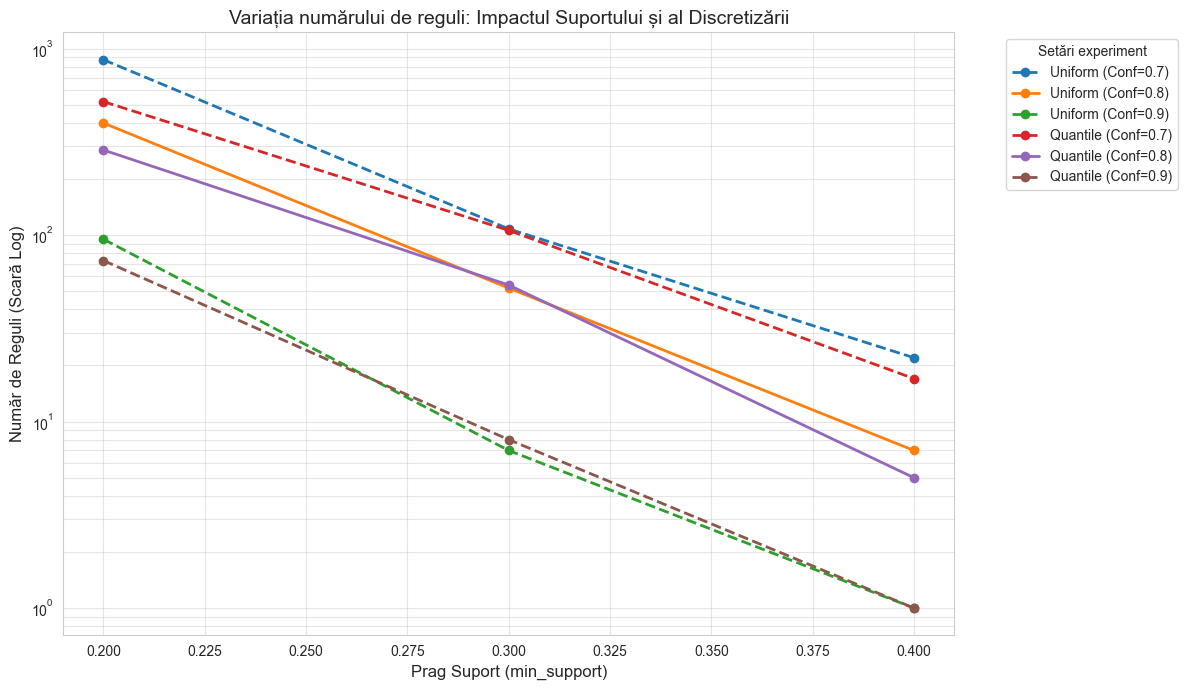

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = pd.DataFrame(plot_data)

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Desenăm linii pentru fiecare strategie, diferențiate prin stilul liniei pentru Încredere
for strat in strategies:
    for c in conf:
        subset = df_plot[(df_plot['Strategie'] == strat) & (df_plot['Incredere'] == c)]
        line_style = '-' if c == 0.8 else '--'
        plt.plot(subset['Suport'], subset['NrReguli'], 
                 marker='o', linestyle=line_style, linewidth=2, 
                 label=f'{strat.capitalize()} (Conf={c})')

plt.yscale('log') # Scară logaritmică pentru a vizualiza mai bine variația mare
plt.title('Variația numărului de reguli: Impactul Suportului și al Discretizării', fontsize=14)
plt.xlabel('Prag Suport (min_support)', fontsize=12)
plt.ylabel('Număr de Reguli (Scară Log)', fontsize=12)
plt.legend(title="Setări experiment", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.tight_layout()
plt.show()

# df_final = apply_discretization(df, strategy='quantile', n_bins=3)
df_final = apply_discretization(df, strategy='uniform', n_bins=3)
freq = apriori(df_final, min_support=0.2, use_colnames=True)
rules = association_rules(freq, metric="confidence", min_threshold=0.8)

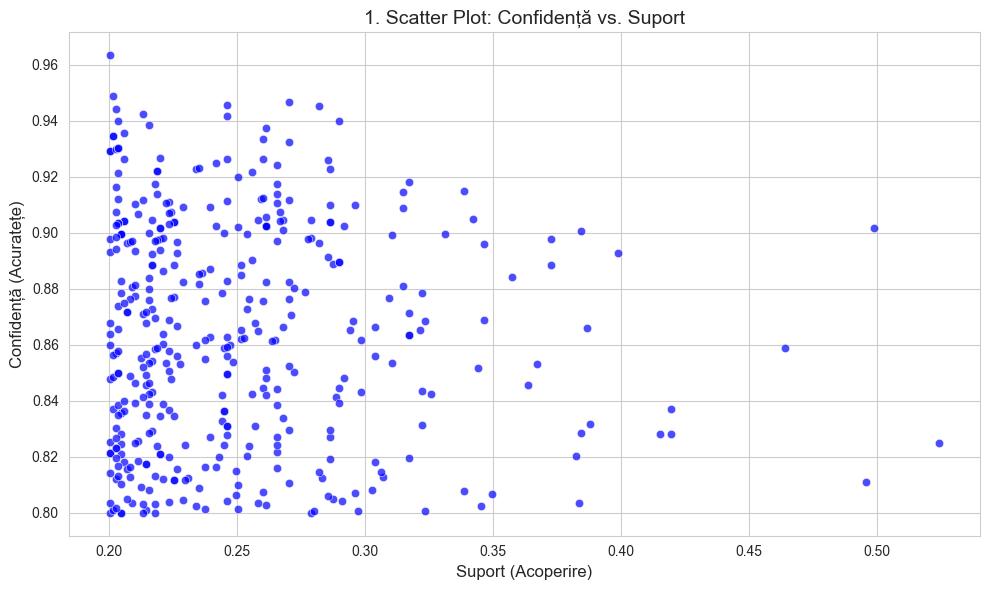

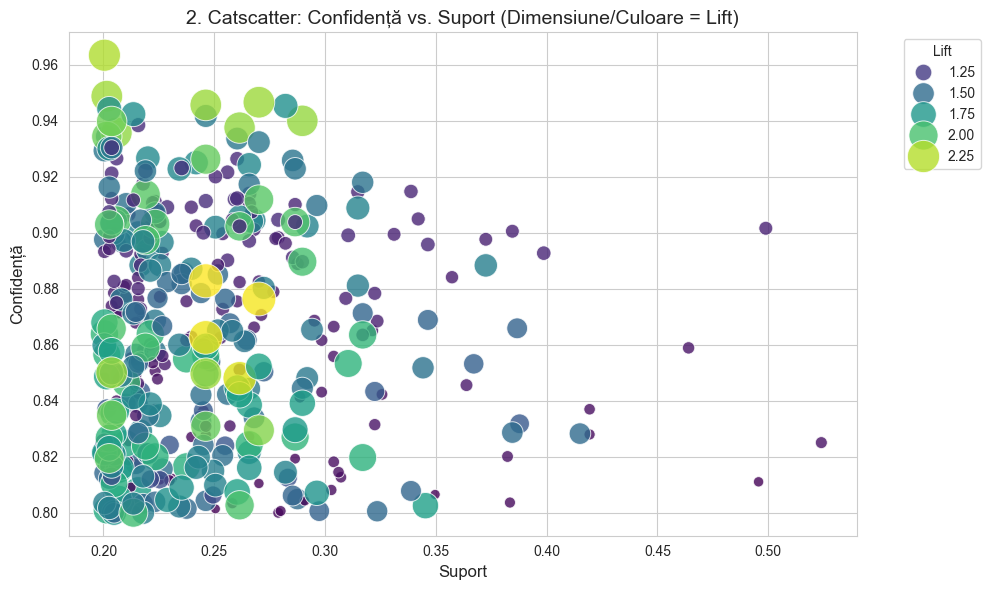

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display, HTML

# Asigură-te că dataframe-ul 'rules' nu este gol
if not rules.empty:
    sns.set_style("whitegrid")
    
    # -------------------------------------------------------------------
    # 1. Scatter plot cu Confidence vs. Support
    # -------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=rules, x='support', y='confidence', alpha=0.7, color='b')
    plt.title('1. Scatter Plot: Confidență vs. Suport', fontsize=14)
    plt.xlabel('Suport (Acoperire)', fontsize=12)
    plt.ylabel('Confidență (Acuratețe)', fontsize=12)
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------------
    # 2. Catscatter (Bubble plot): Dimensiunea punctelor indică Lift-ul
    # -------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    # Dimensiunea (size) și nuanța (hue) sunt dictate de metrica 'lift'
    scatter = sns.scatterplot(
        data=rules, 
        x='support', 
        y='confidence', 
        size='lift', 
        sizes=(50, 600), 
        hue='lift', 
        palette='viridis', 
        alpha=0.8
    )
    plt.title('2. Catscatter: Confidență vs. Suport (Dimensiune/Culoare = Lift)', fontsize=14)
    plt.xlabel('Suport', fontsize=12)
    plt.ylabel('Confidență', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Lift")
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------------
    # 3. Alluvial Plot (Parallel Categories) folosind Plotly
    # -------------------------------------------------------------------
    # Pentru Plotly, trebuie să transformăm frozenset-urile în string-uri lizibile
    rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

    # Pentru a nu obține un grafic ilizibil (supraîncărcat), selectăm top 20 reguli după Lift
    top_rules = rules.sort_values('lift', ascending=False).head(20)

    fig = px.parallel_categories(
        top_rules,
        dimensions=['antecedents_str', 'consequents_str'],
        color='lift',
        color_continuous_scale=px.colors.sequential.Inferno,
        labels={'antecedents_str': 'Antecedenți', 'consequents_str': 'Consecvenți'}
    )
    fig.update_layout(
        title="3. Alluvial Plot: Fluxul de la Antecedenți la Consecvenți (Top 20 Reguli)",
        font=dict(size=11),
        margin=dict(t=80, b=80, l=80, r=100) # 't=80' adaugă 80 de pixeli în partea de sus (top) pentru titlu
    )
    fig_html = fig.to_html(full_html=False, include_plotlyjs='cdn')
    display(HTML(fig_html))
else:
    print("Nu există suficiente reguli generate pentru a trasa graficele. Reduceți pragurile de suport/confidență.")

### Cum variază mulțimea de reguli la schimbarea pragurilor de la punctul 2? (2p)

Impactul pragului de suport:

    Se modifică drastic cardinalul mulțimilor de reguli de la un prag fixat de suport la altul. Pentru pragul 0.2 observăm un număr de +100 de mulțimi, timp în care pentru pragul 0.4 numărul asociat mulimilor de reguli este în intervalul [0,100]. În concluzie, mulțimile de reguli mai generale (potențial zgomot) au prag de suport > 30%, timp în care cele mai precise (poate prea precise/se poate pierde infomrație utiilă) au prag de suport < 30%.

Impactul pragului de încredere:

    Pragul de încredere shift-ează masiv numărul de reguli funcționând ca un filtru de calitate. Astfel cu cât pragul de încredere crește, cu atât vom depista un cardinal a mulțimilor de reguli mai scăzut. Pragul de 0.7 introduce mult zgomot, timp în care pragul de 0.9 reține doar certitudinile clinice/relevante.

### Care metodă de discretizare a datelor este de preferat pentru setul supus analizei? (2p)

Transformată de discretizare uniformă

    O transformare de discretizare uniformă va păstra distribuția de probabilitate a fiecărei variabile de intrare, dar o va face discretă cu numărul specificat de grupuri ordinale sau etichete. Putem aplica transformarea de discretizare uniformă folosind clasa KBinsDiscretizer și setând argumentul „strategy” la „uniform”. (Citat din https://machinelearningmastery.com/discretization-transforms-for-machine-learning/)

Transformată de discretizare cuantilă

    O transformare de discretizare cuantilă va încerca să împartă observațiile pentru fiecare variabilă de intrare în k grupuri, unde numărul de observații atribuite fiecărui grup este aproximativ egal. Cu excepția cazului în care există un număr mare de observații sau o distribuție empirică complexă, numărul de intervale trebuie menținut mic, cum ar fi 5-10. (Citat din https://machinelearningmastery.com/discretization-transforms-for-machine-learning/)

Răspuns

    Metoda de dicretizare uniformă lasă un surplus de date care pot fi redundante, timp în care transformare de discretizare cuantilă oferă un echilibru între date ceea ce previne situația în care pragul de suport elimină automat categorii întregi de pacienți (cum ar fi cei cu colesterol extrem de mare) doar pentru că sunt puțini la număr.


### Extrageți reguli utile și motivați (2p)

Regula 1:

    === Strategia QUANTILE: 73 reguli găsite (Suport=0.2, Confidență=0.9) ===
    Antecedents: frozenset({'ST_Slope_ST_Slope=Up', 'RestingECG_RestingECG=Normal', 'FastingBS_FastingBS=0' 'ExerciseAngina_ExerciseAngina=N'}) => Consequents: frozenset({'HeartDisease_HeartDisease=0'})
    - Support: 0.2037
    - Confidence: 0.9397
    - Lift: 2.1040

Oferă date pentru un pacient sănătos cu o probabilitate de aproximativ 94%. Această regilă este extrem utilă pentru eficientizarea selectării pacienților și resurselor (fără teste suplimentare inutile).


Regula 2:

    === Strategia UNIFORM: 9 reguli găsite (Suport=0.3, Confidență=0.9) ===
    Antecedents: frozenset({'ST_Slope_ST_Slope=Flat', 'ChestPainType_ChestPainType=ASY'}) => Consequents: frozenset({'HeartDisease_HeartDisease=1'})
    - Support: 0.3148
    - Confidence: 0.9088
    - Lift: 1.6423

Datele acestea ilustrează pacientul diagnosticat, dar care nu prezintă simptome evidente (dureroase) - ChestPainType=ASY! Extrem de utilă pentru a evita netratarea bolii la timp, din cauza lipselor semnelor de întrebare.

### Ce reguli pot fi extrase pentru a construi un clasificator? Comentați asupra calității acestora din punct de vedere al acurateței (confidență) și acoperirii (suport)(3p)

Comentariu pe baza Acc și Suport.